# 01 · Exploratory data analysis

Goals of this notebook (spec milestone 2):

1. Document the data source and its caveats.
2. Show the dataset size at each cleaning step.
3. Measure the class balance of the target, `y = 1 if goals + assists >= 1`, on the rows the model predicts for. The majority-class baseline is the number every model has to beat.
4. Look at the signals the features are built on: minutes, attacking threat, xG/xA availability, and opponent strength.

Inputs: `data/processed/clean.parquet`, `team_matches.parquet` and `cleaning_log.csv`, produced by `python -m src.scrape` and `python -m src.clean`. Figures are also saved to `reports/figures/eda_*.png`.

## 1. Data source and caveats

- **Source.** The spec's first choice, FBref, sits behind a Cloudflare interactive challenge (HTTP 403 on every page, including `robots.txt`). Getting past that would mean evading bot protection, so we use the spec's documented fallback: official **Fantasy Premier League (FPL)** data from the `vaastav/Fantasy-Premier-League` GitHub archive of per-gameweek FPL API snapshots (`merged_gw.csv`, `players_raw.csv`, `teams.csv`, `fixtures.csv`).
- **Seasons.** 2020-21 to 2025-26: six complete Premier League seasons of 38 gameweeks. The in-progress 2026-27 season is excluded.
- **Unit and key.** One row per player per fixture. The player key is FPL's `code`, which is stable across seasons (FPL's per-season `element` id is not).
- **No shots.** FPL has no shot counts. We use FPL's `threat` (an Opta-derived index driven mainly by shots and touches in dangerous areas) and `creativity` instead.
- **xG/xA only from 2022-23, in practice from its gameweek 16.** `expected_goals` / `expected_assists` do not exist in FPL data before 2022-23, so they are NaN there and treated as optional features. In 2022-23 the archive holds zeros rather than missing values until FPL started publishing them; cleaning turns those zeros into NaN (section 5).
- **Assists use FPL's definition**, which is broader than the official Opta one (for example, a shot that is saved and scored on the rebound can earn an assist).
- **Position** is the player's FPL classification for the season (GK/DEF/MID/FWD), not the role played in a given match.
- **Minutes rule (design option A).** Rows with 0 minutes are not appearances and are dropped. Appearances under 30 minutes are kept because they feed rolling form, but they are not prediction rows. The model only predicts rows with `minutes >= 30` (`eligible`), so **every prediction is conditional on the player playing at least 30 minutes**, which is not known before kickoff.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists() and (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import load_config, resolve

cfg = load_config()
FIG_DIR = resolve(cfg["paths"]["figures_dir"])
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "axes.axisbelow": True, "axes.titlesize": 11,
})
BLUE, GRAY = "#2a78d6", "#898781"
SPLIT_COLORS = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}
TIER_COLORS = ["#86b6ef", "#2a78d6", "#104281"]


def savefig(fig, name):
    fig.savefig(FIG_DIR / f"eda_{name}.png", dpi=120, bbox_inches="tight")


clean = pd.read_parquet(resolve(cfg["paths"]["clean"])).reset_index(drop=True)
team = pd.read_parquet(resolve(cfg["paths"]["team_matches"])).reset_index(drop=True)
clean_log = pd.read_csv(resolve(cfg["paths"]["cleaning_log"]))
MIN_MINUTES = cfg["cleaning"]["min_minutes"]

In [2]:
print(f"clean.parquet: {len(clean):,} appearances (minutes > 0) by {clean['player_id'].nunique():,} outfield players, "
      f"kickoffs {clean['date'].min():%Y-%m-%d} to {clean['date'].max():%Y-%m-%d}")
print(f"team_matches.parquet: {len(team):,} team-match rows = {team.groupby('season')['fixture_id'].nunique().sum():,} fixtures")

overview = clean.groupby("season").agg(
    appearances=("player_id", "size"),
    eligible=("eligible", "sum"),
    players=("player_id", "nunique"),
    gameweeks=("matchweek", "nunique"),
)
overview["fixtures"] = team.groupby("season")["fixture_id"].nunique()
overview["eligible_share"] = overview["eligible"] / overview["appearances"]
overview

clean.parquet: 62,054 appearances (minutes > 0) by 1,270 outfield players, kickoffs 2020-09-12 to 2026-05-24
team_matches.parquet: 4,560 team-match rows = 2,280 fixtures


,appearances,eligible,players,gameweeks,fixtures,eligible_share
season,,,,,,
2020-21,9628,7926,483,38,380,0.8232
2021-22,9722,7958,495,38,380,0.8186
2022-23,10575,8091,515,37,380,0.7651
2023-24,10608,8063,530,38,380,0.7601
2024-25,10796,8103,518,38,380,0.7506
2025-26,10725,8107,497,38,380,0.7559


## 2. Cleaning log

Row counts before and after each cleaning step (spec section 4), as written by `src/clean.py`. `pct_of_raw` is `rows_after` as a share of the raw player-match rows.

In [3]:
scrape_log_path = resolve(cfg["paths"]["raw_dir"]) / "scrape_log.csv"
if scrape_log_path.exists():
    print("Scrape log (data/raw/scrape_log.csv):")
    display(pd.read_csv(scrape_log_path))

log = clean_log.copy()
is_step = log["step"].astype(str).str.fullmatch(r"\d+[a-z]?")
funnel = log.loc[is_step].copy() if is_step.any() else log.copy()
funnel["pct_of_raw"] = (100 * funnel["rows_after"] / funnel["rows_before"].iloc[0]).round(1)
with pd.option_context("display.max_colwidth", 100):
    print("Player-match cleaning steps (data/processed/cleaning_log.csv):")
    display(funnel.set_index("step"))
    if is_step.any() and (~is_step).any():
        print("Other log lines (team table and per-season summaries):")
        display(log.loc[~is_step].set_index("step"))

n_elig = int(clean["eligible"].sum())
print(f"Raw player-match rows:                       {int(funnel['rows_before'].iloc[0]):,}")
print(f"Appearances kept (outfield, minutes > 0):    {len(clean):,}")
print(f"Prediction rows (eligible, minutes >= {MIN_MINUTES}):   {n_elig:,}")

Scrape log (data/raw/scrape_log.csv):


,season,player_match_rows,team_match_rows,fixtures,unique_players,downloaded_files,cached_files,status
0,2020-21,24365,760,380,713,0,4,ok
1,2021-22,25447,760,380,737,0,4,ok
2,2022-23,26505,760,380,778,0,4,ok
3,2023-24,29725,760,380,865,0,4,ok
4,2024-25,27283,760,380,784,0,4,ok
5,2025-26,29757,760,380,841,0,4,ok


Player-match cleaning steps (data/processed/cleaning_log.csv):


,description,rows_before,rows_after,rows_removed,pct_of_raw
step,,,,,
0,raw rows loaded (dtypes enforced),163082,163082,0,100.0
1,drop exact duplicate rows,163082,163072,10,100.0
2,"dedupe on (player_id, date): 0 duplicate groups (0 rows; 0 span >1 fixture_id, 0 span >1 team); ...",163072,163072,0,100.0
3,"drop rows missing key fields (missing counts: {'date': 0, 'player_id': 0, 'minutes': 0})",163072,163072,0,100.0
4,"fill missing count stats with 0 (filled: {'goals': 0, 'assists': 0, 'threat': 0, 'creativity': 0...",163072,163072,0,100.0
4b,set xg/xa/starts to NaN in gameweeks where every non-null xg and xa is 0 (not yet published): 84...,163072,163072,0,100.0
5,drop positions ['GK'],163072,144894,18178,88.8
6,drop minutes == 0 (not an appearance),144894,62054,82840,38.1
6b,"eligible = minutes >= 30: rows_after is the eligible count (flag only, nothing dropped; rows_rem...",62054,48248,13806,29.6


Other log lines (team table and per-season summaries):


,description,rows_before,rows_after,rows_removed
step,,,,
team,"team_matches: drop incomplete rows, dedupe on (season, fixture_id, team)",4560,4560,0
summary,2020-21: appearances -> eligible rows; eligible base rate (goals+assists>=1) = 0.1861; players =...,9628,7926,1702
summary,2021-22: appearances -> eligible rows; eligible base rate (goals+assists>=1) = 0.1875; players =...,9722,7958,1764
summary,2022-23: appearances -> eligible rows; eligible base rate (goals+assists>=1) = 0.1874; players =...,10575,8091,2484
summary,2023-24: appearances -> eligible rows; eligible base rate (goals+assists>=1) = 0.2092; players =...,10608,8063,2545
summary,2024-25: appearances -> eligible rows; eligible base rate (goals+assists>=1) = 0.1908; players =...,10796,8103,2693
summary,2025-26: appearances -> eligible rows; eligible base rate (goals+assists>=1) = 0.1837; players =...,10725,8107,2618
summary,all seasons: appearances -> eligible rows; eligible base rate = 0.1908,62054,48248,13806


Raw player-match rows:                       163,082
Appearances kept (outfield, minutes > 0):    62,054
Prediction rows (eligible, minutes >= 30):   48,248



**Takeaway.** The 163,082 raw player-match rows (every registered player in every gameweek) come down to 62,054 outfield appearances.

- By far the biggest cut is the 82,840 zero-minute rows: unused substitutes and squad players, which are not appearances.
- Dropping goalkeepers removes 18,178 rows.
- Only 10 exact duplicates were found, with no (player_id, date) duplicates and no missing key fields.
- Step 4b drops nothing: it sets `xg`/`xa`/`starts` to NaN in 2022-23 gameweeks 1-15, where the archive has zeros because FPL had not yet published them (section 5).
- 48,248 appearances (77.8% of appearances, 29.6% of raw rows) have at least 30 minutes. These are the prediction rows.
- 2022-23 shows 37 distinct gameweeks but still 380 fixtures. Gameweek 7 was postponed in September 2022 and its fixtures were played in later gameweeks.


## 3. Target and base rate

On eligible rows only (the rows the model predicts for): `y = 1 if goals + assists >= 1 else 0`. The split follows `config.yaml`: train 2020-21 to 2023-24, validation 2024-25, test 2025-26. The majority-class baseline predicts `y = 0` for every row, so its accuracy is `1 - base_rate`.

In [4]:
elig = clean.loc[clean["eligible"]].copy()
elig["y"] = ((elig["goals"] + elig["assists"]) >= 1).astype(int)

split_of = {s: "train" for s in cfg["split"]["train_seasons"]}
split_of[cfg["split"]["val_season"]] = "val"
split_of[cfg["split"]["test_season"]] = "test"
elig["split"] = pd.Categorical(elig["season"].map(split_of), categories=["train", "val", "test"], ordered=True)
elig["position"] = pd.Categorical(elig["position"], categories=["DEF", "MID", "FWD"], ordered=True)

y = elig["y"]
base = y.mean()
print("y.value_counts(normalize=True) on all eligible rows:")
print(y.value_counts(normalize=True).sort_index().round(4))
print(f"\nn = {len(y):,} | base rate P(y=1) = {base:.4f} | majority-class (always 0) accuracy = {1 - base:.4f}")

y.value_counts(normalize=True) on all eligible rows:
y
0    0.8092
1    0.1908
Name: proportion, dtype: float64

n = 48,248 | base rate P(y=1) = 0.1908 | majority-class (always 0) accuracy = 0.8092


In [5]:
print("y.value_counts(normalize=True) per split:")
for name, part in elig.groupby("split", observed=True):
    vc = part["y"].value_counts(normalize=True).sort_index()
    seasons_in = ", ".join(sorted(part["season"].unique()))
    print(f"  {name:5s} [{seasons_in}]  n = {len(part):,}  P(y=0) = {vc.get(0, 0.0):.4f}  P(y=1) = {vc.get(1, 0.0):.4f}")


def rate_table(df, by):
    t = df.groupby(by, observed=True)["y"].agg(rows="size", positives="sum", base_rate="mean")
    t["majority_acc"] = 1 - t["base_rate"]
    return t


for by in ["season", "split", "position", "home_away"]:
    print(f"\nBase rate by {by}:")
    display(rate_table(elig, by))

print("\nBase rate by position and split:")
display(elig.pivot_table(index="position", columns="split", values="y", aggfunc="mean", observed=True))

y.value_counts(normalize=True) per split:
  train [2020-21, 2021-22, 2022-23, 2023-24]  n = 32,038  P(y=0) = 0.8074  P(y=1) = 0.1926
  val   [2024-25]  n = 8,103  P(y=0) = 0.8092  P(y=1) = 0.1908
  test  [2025-26]  n = 8,107  P(y=0) = 0.8163  P(y=1) = 0.1837

Base rate by season:


,rows,positives,base_rate,majority_acc
season,,,,
2020-21,7926,1475,0.1861,0.8139
2021-22,7958,1492,0.1875,0.8125
2022-23,8091,1516,0.1874,0.8126
2023-24,8063,1687,0.2092,0.7908
2024-25,8103,1546,0.1908,0.8092
2025-26,8107,1489,0.1837,0.8163



Base rate by split:


,rows,positives,base_rate,majority_acc
split,,,,
train,32038,6170,0.1926,0.8074
val,8103,1546,0.1908,0.8092
test,8107,1489,0.1837,0.8163



Base rate by position:


,rows,positives,base_rate,majority_acc
position,,,,
DEF,19535,1887,0.0966,0.9034
MID,23059,5310,0.2303,0.7697
FWD,5654,2008,0.3551,0.6449



Base rate by home_away:


,rows,positives,base_rate,majority_acc
home_away,,,,
A,24219,4288,0.1771,0.8229
H,24029,4917,0.2046,0.7954



Base rate by position and split:


split,train,val,test
position,,,
DEF,0.0974,0.0909,0.0988
MID,0.2316,0.2317,0.2237
FWD,0.3577,0.3788,0.3227


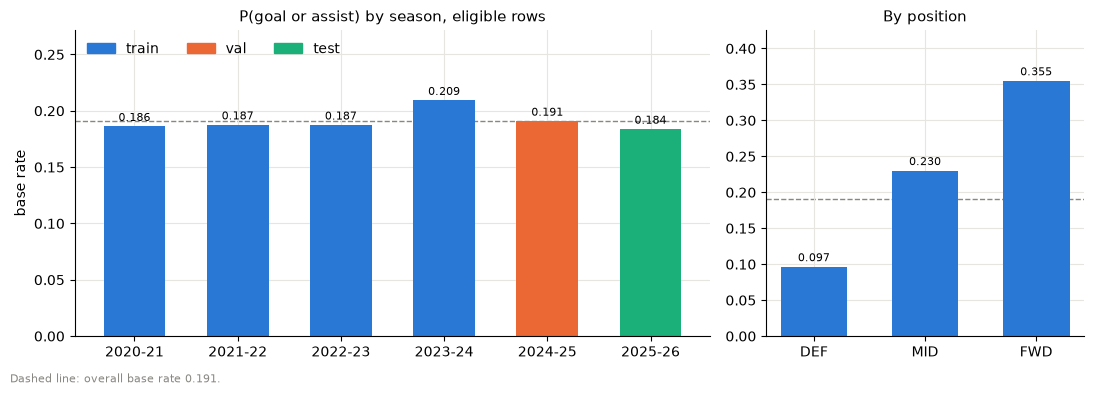

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [2, 1]})

by_season = rate_table(elig, "season")
bars = axes[0].bar(by_season.index, by_season["base_rate"], width=0.6,
                   color=[SPLIT_COLORS[split_of[s]] for s in by_season.index])
axes[0].bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
axes[0].axhline(base, color=GRAY, ls="--", lw=1, zorder=0.5)
axes[0].legend(handles=[Patch(color=c, label=s) for s, c in SPLIT_COLORS.items()], frameon=False,
               loc="upper left", ncols=3)
axes[0].set(title="P(goal or assist) by season, eligible rows", ylabel="base rate",
            ylim=(0, by_season["base_rate"].max() * 1.3))

by_pos = rate_table(elig, "position")
bars = axes[1].bar(by_pos.index.astype(str), by_pos["base_rate"], width=0.6, color=BLUE)
axes[1].bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
axes[1].axhline(base, color=GRAY, ls="--", lw=1, zorder=0.5)
axes[1].set(title="By position", ylim=(0, by_pos["base_rate"].max() * 1.2))
fig.text(0.01, -0.02, f"Dashed line: overall base rate {base:.3f}.", color=GRAY, fontsize=8)
fig.tight_layout()
savefig(fig, "base_rate")
plt.show()


**Takeaway.** On the 48,248 eligible rows the base rate is **0.1908**. A player who plays at least 30 minutes records a goal or assist about 19% of the time, so always predicting "no" is **80.9% accurate**. That is the number to beat, and it is why accuracy alone is not a useful metric here.

- **By split:** the rate is stable (train 0.1926, validation 0.1908, test 0.1837). The test season is the lowest of the six, which lifts its majority-class accuracy to 0.8163. 2023-24 is the highest (0.2092), matching its high goals-conceded numbers in section 6.
- **By position:** position dominates. DEF 0.0966, MID 0.2303, FWD 0.3551, so majority-class accuracy is 0.9034, 0.7697 and 0.6449. Per-position results must be read against these different baselines.
- **Forwards in the test season** (0.3227) are well below validation (0.3788) and train (0.3577).
- **Home vs away:** home rows beat away rows, 0.2046 against 0.1771.


## 4. Distributions

### 4a. Minutes played

All appearances (minutes > 0), including the short ones that are not prediction rows. The right panel shows why a 30-minute cut is sensible: a cameo gives a player far less time to contribute, so it is a different prediction problem from a start.

Appearances with minutes < 30: 22.2% of 62,054
Minutes quantiles: {0.1: 12.0, 0.25: 45.0, 0.5: 86.0, 0.75: 90.0, 0.9: 90.0}
P(goal or assist): below the cut 0.0717, at or above 0.1908


,rows,share_of_rows,p_goal_or_assist,ga_per90,def_share
minutes_bin,,,,,
1-15,8074,0.1301,0.0513,0.6604,0.2378
16-29,5732,0.0924,0.1005,0.4411,0.1673
30-45,3888,0.0627,0.1024,0.2565,0.2744
46-60,1967,0.0317,0.0935,0.1667,0.2359
61-75,6307,0.1016,0.1822,0.2898,0.1833
76-89,6128,0.0988,0.2805,0.3802,0.2131
90,29958,0.4828,0.1921,0.2287,0.5188


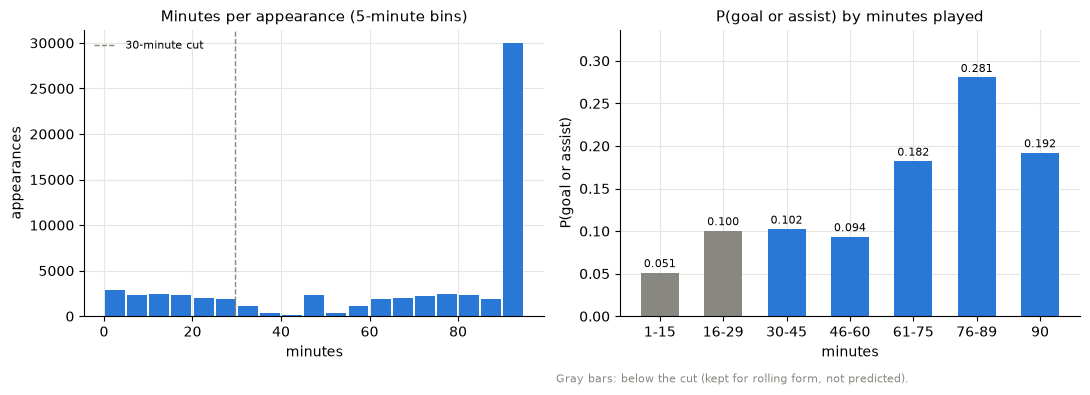

In [7]:
m = clean["minutes"]
print(f"Appearances with minutes < {MIN_MINUTES}: {(m < MIN_MINUTES).mean():.1%} of {len(m):,}")
print("Minutes quantiles:", {q: float(v) for q, v in m.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).items()})

edges = [0, 15, MIN_MINUTES - 1, 45, 60, 75, 89, np.inf]
labels = ["1-15", f"16-{MIN_MINUTES - 1}", f"{MIN_MINUTES}-45", "46-60", "61-75", "76-89",
          "90" if m.max() <= 90 else "90+"]
mins = clean.assign(
    ga=clean["goals"] + clean["assists"],
    y=((clean["goals"] + clean["assists"]) >= 1).astype(int),
    is_def=(clean["position"] == "DEF").astype(int),
    minutes_bin=pd.cut(clean["minutes"], bins=edges, labels=labels),
)
below = mins["minutes"] < MIN_MINUTES
print(f"P(goal or assist): below the cut {mins.loc[below, 'y'].mean():.4f}, at or above {mins.loc[~below, 'y'].mean():.4f}")
by_min = mins.groupby("minutes_bin", observed=True).agg(
    rows=("y", "size"), p_goal_or_assist=("y", "mean"), ga_sum=("ga", "sum"), minutes_sum=("minutes", "sum"),
    def_share=("is_def", "mean"))
by_min["share_of_rows"] = by_min["rows"] / by_min["rows"].sum()
by_min["ga_per90"] = 90 * by_min["ga_sum"] / by_min["minutes_sum"]
by_min = by_min[["rows", "share_of_rows", "p_goal_or_assist", "ga_per90", "def_share"]]
display(by_min)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(m, bins=np.arange(0, m.max() + 6, 5), color=BLUE, rwidth=0.9)
axes[0].axvline(MIN_MINUTES - 0.5, color=GRAY, ls="--", lw=1, label=f"{MIN_MINUTES}-minute cut")
axes[0].legend(frameon=False, fontsize=8, loc="best")
axes[0].set(title="Minutes per appearance (5-minute bins)", xlabel="minutes", ylabel="appearances")

colors = [GRAY if lab in labels[:2] else BLUE for lab in by_min.index]
bars = axes[1].bar(by_min.index.astype(str), by_min["p_goal_or_assist"], color=colors, width=0.6)
axes[1].bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
axes[1].set(title="P(goal or assist) by minutes played", xlabel="minutes", ylabel="P(goal or assist)",
            ylim=(0, by_min["p_goal_or_assist"].max() * 1.2))
fig.text(0.51, -0.02, "Gray bars: below the cut (kept for rolling form, not predicted).", color=GRAY, fontsize=8)
fig.tight_layout()
savefig(fig, "minutes")
plt.show()


**Takeaway.** Minutes are strongly bimodal: 48% of appearances are full 90-minute games, and 22.2% last under 30 minutes (mostly late substitute cameos).

- **Below vs above the cut:** the goal-contribution rate is 0.072 below 30 minutes and 0.191 at or above it.
- **Within eligible rows** the rate rises from about 0.10 for 30-60 minutes to 0.28 for 76-89 minutes.
- **The dip at exactly 90** (0.192) is a position-mix effect: 52% of full-match rows are defenders, who are rarely substituted, against 17-27% in the other bins.
- **The 30-minute line is a pragmatic cut, not a sharp break** (16-29 and 30-45 have similar rates). It removes the shortest cameos, where the outcome mostly reflects the substitution decision rather than the player.
- **Per-90 needs a minimum-minutes guard (`p90_min_minutes`):** short cameos have inflated, noisy per-90 rates (0.66 goals + assists per 90 for 1-15 minutes).


### 4b. Goals and assists per match (eligible rows)

In [8]:
def share_0_to_3plus(s):
    return s.clip(upper=3).value_counts(normalize=True).reindex(range(4), fill_value=0.0)


ga = elig["goals"] + elig["assists"]
dist = pd.DataFrame({
    "goals": share_0_to_3plus(elig["goals"]),
    "assists": share_0_to_3plus(elig["assists"]),
    "goals + assists": share_0_to_3plus(ga),
})
dist.index = ["0", "1", "2", "3+"]
dist.index.name = "per match"
print("Share of eligible rows:")
display(dist)

pos = elig.groupby("position", observed=True).agg(
    rows=("y", "size"), goals=("goals", "sum"), assists=("assists", "sum"), minutes=("minutes", "sum"))
pos["goals_per90"] = 90 * pos["goals"] / pos["minutes"]
pos["assists_per90"] = 90 * pos["assists"] / pos["minutes"]
print("Per-90 rates by position (eligible rows):")
display(pos[["rows", "goals_per90", "assists_per90"]])

pos_rows = elig.loc[elig["y"] == 1]
kind = np.select([(pos_rows["goals"] > 0) & (pos_rows["assists"] > 0), pos_rows["goals"] > 0],
                 ["goal and assist", "goal only"], "assist only")
print("Positive rows by kind:")
print(pd.Series(kind).value_counts(normalize=True).round(4).to_string())

Share of eligible rows:


,goals,assists,goals + assists
per match,,,
0,0.8925,0.9006,0.8092
1,0.0964,0.0914,0.1594
2,0.0097,0.0072,0.0262
3+,0.0014,0.0007,0.0052


Per-90 rates by position (eligible rows):


,rows,goals_per90,assists_per90
position,,,
DEF,19535,0.0434,0.0662
MID,23059,0.1600,0.1592
FWD,5654,0.3700,0.1656


Positive rows by kind:
goal only          0.4792
assist only        0.4363
goal and assist    0.0845



**Takeaway.** Multi-contribution matches are rare: 80.9% of eligible rows have no goal or assist, 15.9% have exactly one, and 3.1% have two or more. A binary target therefore loses little information.

- **Goals vs assists:** positive rows split fairly evenly (47.9% goal only, 43.6% assist only, 8.5% both), which supports counting assists in the target.
- **Per 90 by position:** forwards score 0.37 goals per 90, midfielders 0.16 and defenders 0.04. Midfielders and forwards assist at about the same rate (0.16 per 90).


### 4c. Attacking threat vs goal-contribution rate

FPL's `threat` stands in for shots. Left: the **same-match** threat, which is descriptive only (it is measured during the match, so it cannot be a feature). Right: the player's mean threat over their **previous 5 appearances**, computed strictly before the match (the same construction as `threat_roll5` in `src/features.py`), which is available before kickoff. Rows are grouped into deciles; tied values (many rows have a same-match threat of exactly 0) stay in one bin, so the left panel has fewer than 10 points.

Eligible rows with no prior appearance (threat_prior5 is NaN): 653
Same-match threat bins:


,rows,threat_mean,rate
bin,,,
1,18423,0.6606,0.0519
2,4284,3.8604,0.0871
3,2803,5.7082,0.1117
4,4156,7.9439,0.1321
5,4369,12.3850,0.1698
6,4959,19.5796,0.3095
7,4505,29.4357,0.4200
8,4749,54.1324,0.5989


Prior-5 mean threat bins:


,rows,threat_mean,rate
bin,,,
1,5336,0.5517,0.0787
2,4260,1.9001,0.0944
3,5177,3.4041,0.1209
4,4601,5.1839,0.1365
5,4812,7.1730,0.1459
6,4452,9.4395,0.1750
7,4819,12.3018,0.1955
8,4693,16.4307,0.2506
9,4754,22.9561,0.3176


Top/bottom bin rate ratio: same-match 11.5x, prior-5 5.2x


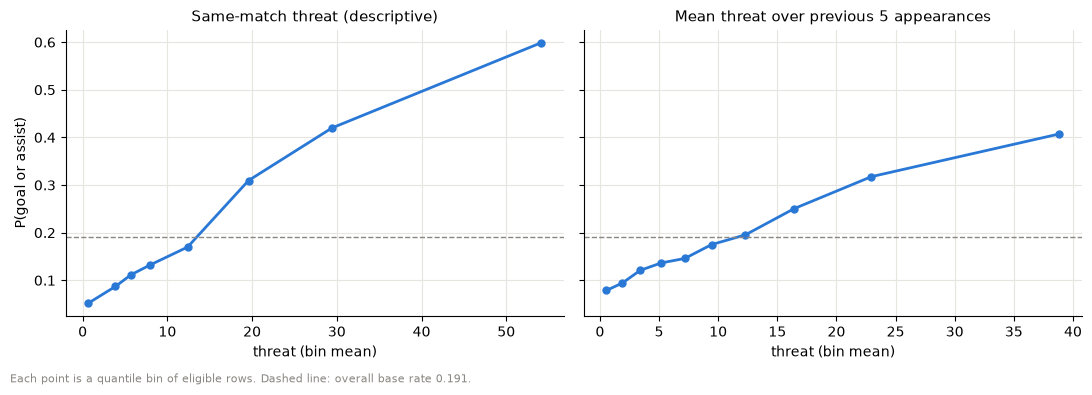

In [9]:
order = clean.sort_values(["player_id", "date", "fixture_id"])
prior5 = order.groupby("player_id")["threat"].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
elig["threat_prior5"] = prior5


def decile_rate(x, target):
    frame = pd.DataFrame({"x": x, "y": target}).dropna()
    frame["bin"] = pd.qcut(frame["x"], 10, duplicates="drop")
    out = frame.groupby("bin", observed=True).agg(rows=("y", "size"), threat_mean=("x", "mean"), rate=("y", "mean"))
    out.index = pd.RangeIndex(1, len(out) + 1, name="bin")
    return out


same = decile_rate(elig["threat"], elig["y"])
prior = decile_rate(elig["threat_prior5"], elig["y"])
print(f"Eligible rows with no prior appearance (threat_prior5 is NaN): {elig['threat_prior5'].isna().sum():,}")
print("Same-match threat bins:")
display(same)
print("Prior-5 mean threat bins:")
display(prior)
print(f"Top/bottom bin rate ratio: same-match {same['rate'].iloc[-1] / same['rate'].iloc[0]:.1f}x, "
      f"prior-5 {prior['rate'].iloc[-1] / prior['rate'].iloc[0]:.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, tab, title in [(axes[0], same, "Same-match threat (descriptive)"),
                       (axes[1], prior, "Mean threat over previous 5 appearances")]:
    ax.plot(tab["threat_mean"], tab["rate"], color=BLUE, lw=2, marker="o", ms=5)
    ax.axhline(base, color=GRAY, ls="--", lw=1)
    ax.set(title=title, xlabel="threat (bin mean)")
axes[0].set_ylabel("P(goal or assist)")
fig.text(0.01, -0.02, f"Each point is a quantile bin of eligible rows. Dashed line: overall base rate {base:.3f}.",
         color=GRAY, fontsize=8)
fig.tight_layout()
savefig(fig, "threat")
plt.show()


**Takeaway.** `threat` is a strong stand-in for shot volume.

- **Same-match threat** separates outcomes sharply: 0.05 in the lowest bin against 0.60 in the highest (11.5x). This is descriptive only.
- **Prior-5 mean threat** is measured before kickoff and still rises monotonically: 0.079 in the bottom decile against 0.407 in the top decile (5.2x). It is the main form signal available to the model, together with its per-90 version.
- **Debuts:** 653 eligible rows have no earlier appearance at all, so their rolling features are NaN.


## 5. xG / xA availability by season

In [10]:
avail = clean[["xg", "xa", "starts"]].notna().groupby(clean["season"]).mean()
avail.columns = [f"{c}_nonmissing" for c in avail.columns]

# A gameweek whose xG values are all 0 means FPL had not published expected stats yet (zeros, not NaN).
per_gw = clean.groupby(["season", "matchweek"])["xg"].sum().rename("xg_sum").reset_index()
pub_gw = per_gw.loc[per_gw["xg_sum"] > 0, ["season", "matchweek"]]
pub_keys = pd.MultiIndex.from_frame(pub_gw)
clean_pub = pd.Series(pd.MultiIndex.from_frame(clean[["season", "matchweek"]]).isin(pub_keys), index=clean.index)
avail["xg_published_share"] = clean_pub.groupby(clean["season"]).mean()
avail["first_gw_with_xg"] = pub_gw.groupby("season")["matchweek"].min()
avail = avail.join(clean.groupby("season")[["goals", "xg", "assists", "xa"]].sum(min_count=1))
print("Per season: share of appearances with non-missing xg/xa/starts, share in gameweeks where FPL published xG, "
      "and season totals:")
display(avail)

zero_filled = clean["xg"].notna() & ~clean_pub
print(f"Appearances with xg present but in a gameweek with no published xG (zero-filled): {zero_filled.sum():,}")
if zero_filled.any():
    display(clean.loc[zero_filled].groupby("season").agg(
        rows=("xg", "size"), first_gw=("matchweek", "min"), last_gw=("matchweek", "max"),
        xg_sum=("xg", "sum"), xa_sum=("xa", "sum"), starts_sum=("starts", "sum")))

elig_pub = pd.Series(pd.MultiIndex.from_frame(elig[["season", "matchweek"]]).isin(pub_keys), index=elig.index)
print("Share of eligible rows with published xG, by split:")
print(elig_pub.groupby(elig["split"], observed=True).mean().round(4).to_string())

Per season: share of appearances with non-missing xg/xa/starts, share in gameweeks where FPL published xG, and season totals:


,xg_nonmissing,xa_nonmissing,starts_nonmissing,xg_published_share,first_gw_with_xg,goals,xg,assists,xa
season,,,,,,,,,
2020-21,0.0000,0.0000,0.0000,0.0000,NaN,985,NaN,903,NaN
2021-22,0.0000,0.0000,0.0000,0.0000,NaN,1037,NaN,926,NaN
2022-23,0.6445,0.6445,0.6445,0.6445,16.0,1038,731.3186,923,438.1431
2023-24,1.0000,1.0000,1.0000,1.0000,1.0,1196,1198.4600,1069,751.1000
2024-25,1.0000,1.0000,1.0000,1.0000,1.0,1081,1100.6400,967,710.3100
2025-26,1.0000,1.0000,1.0000,1.0000,1.0,1005,1068.1700,937,681.8100


Appearances with xg present but in a gameweek with no published xG (zero-filled): 0
Share of eligible rows with published xG, by split:
split
train    0.4143
val      1.0000
test     1.0000



**Takeaway.** xG/xA are only partly usable.

- **2020-21 and 2021-22** have no xG/xA at all (NaN).
- **2022-23 starts late:** FPL only began publishing expected stats (and `starts`) at gameweek 16. The raw archive holds **zeros, not missing values**, for gameweeks 1-15, which would make `xg_roll*` and `xa_roll*` read as 0 instead of NaN. Cleaning step 4b sets these to NaN (8,491 raw rows, 3,759 appearances), so 64.5% of that season's appearances have xG. The check above confirms no zero-filled gameweeks remain.
- **From 2023-24,** season xG totals track goals closely (for example 1,198 xG against 1,196 goals in 2023-24).
- **xA** sits well below FPL assists (751 against 1,069 in 2023-24), consistent with FPL's broader assist definition.
- **Coverage in training:** only 41.4% of train rows have published xG, against 100% of validation and test rows. xG features are mostly missing in training, so they are optional extras; `threat` and `creativity` are the full-coverage signals.


## 6. Team context: opponent strength

Goals conceded per match for each team-season (from `team_matches.parquet`). The season averages below use the whole season, which is fine for description but would leak if used as a feature; the model's `opp_conceded_roll5/10` features use only the opponent's matches before the fixture.

In [11]:
ts = team.groupby(["season", "team"]).agg(
    matches=("fixture_id", "size"), ga_per_match=("goals_against", "mean"), gf_per_match=("goals_for", "mean")
).reset_index()
print("Goals conceded per match across the 20 teams, by season:")
display(ts.groupby("season")["ga_per_match"].describe()[["count", "min", "25%", "50%", "75%", "max", "std"]])
print("Fewest and most conceded per match (team-seasons):")
display(pd.concat([ts.nsmallest(3, "ga_per_match"), ts.nlargest(3, "ga_per_match")])
        [["season", "team", "matches", "ga_per_match"]].reset_index(drop=True))

rank = ts.groupby("season")["ga_per_match"].rank(method="first")
size = ts.groupby("season")["ga_per_match"].transform("size")
tier_labels = ["fewest conceded", "middle", "most conceded"]
ts["opp_tier"] = pd.Categorical(np.array(tier_labels)[(np.ceil(3 * rank / size) - 1).astype(int)],
                                categories=tier_labels, ordered=True)

opp = ts.rename(columns={"team": "opponent", "ga_per_match": "opp_ga_per_match"})[
    ["season", "opponent", "opp_ga_per_match", "opp_tier"]]
elig_opp = elig.merge(opp, on=["season", "opponent"], how="left", validate="many_to_one")
print(f"Eligible rows whose opponent is missing from team_matches: {elig_opp['opp_tier'].isna().sum():,}")

by_tier = elig_opp.pivot_table(index="opp_tier", columns="position", values="y", aggfunc="mean", observed=True)
by_tier["all"] = elig_opp.groupby("opp_tier", observed=True)["y"].mean()
print("P(goal or assist) by opponent tier (season goals conceded per match, thirds within season):")
display(by_tier)
print(f"Most- vs fewest-conceded tier rate ratio (all positions): "
      f"{by_tier['all'].iloc[-1] / by_tier['all'].iloc[0]:.2f}x")

Goals conceded per match across the 20 teams, by season:


,count,min,25%,50%,75%,max,std
season,,,,,,,
2020-21,20.0,0.8421,1.1776,1.2895,1.4934,2.0000,0.2961
2021-22,20.0,0.6842,1.1513,1.4079,1.6579,2.2105,0.4269
2022-23,20.0,0.8684,1.2105,1.3947,1.6908,2.0526,0.3362
2023-24,20.0,0.7632,1.5263,1.6316,1.7632,2.7368,0.4366
2024-25,20.0,0.8947,1.1974,1.3816,1.6513,2.2632,0.3795
2025-26,20.0,0.7105,1.3092,1.3553,1.4539,1.9737,0.2696


Fewest and most conceded per match (team-seasons):


,season,team,matches,ga_per_match
0,2021-22,Liverpool,38,0.6842
1,2021-22,Man City,38,0.6842
2,2025-26,Arsenal,38,0.7105
3,2023-24,Sheffield Utd,38,2.7368
4,2024-25,Southampton,38,2.2632
5,2023-24,Luton,38,2.2368


Eligible rows whose opponent is missing from team_matches: 0
P(goal or assist) by opponent tier (season goals conceded per match, thirds within season):


position,DEF,MID,FWD,all
opp_tier,,,,
fewest conceded,0.0724,0.1789,0.2721,0.1465
middle,0.0900,0.2245,0.3668,0.1863
most conceded,0.1242,0.2797,0.4137,0.2332


Most- vs fewest-conceded tier rate ratio (all positions): 1.59x


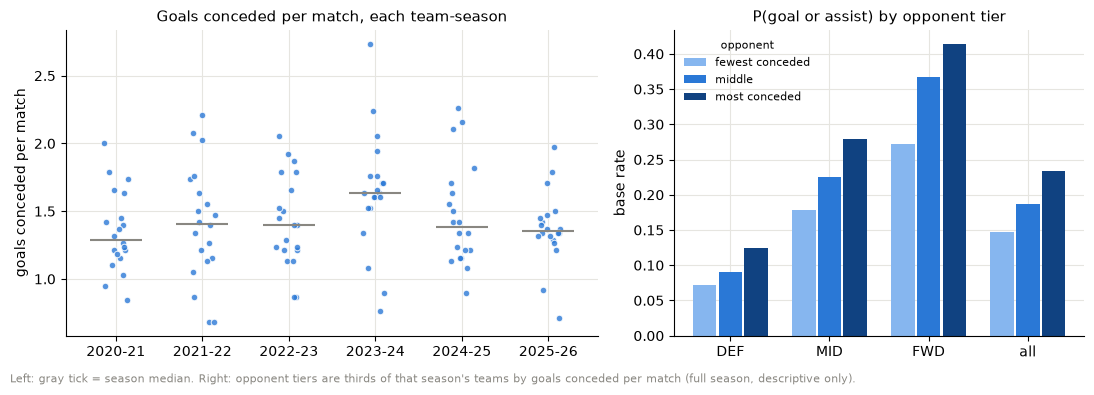

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
season_list = sorted(ts["season"].unique())
rng = np.random.default_rng(cfg["project"]["random_seed"])
for i, s in enumerate(season_list):
    vals = ts.loc[ts["season"] == s, "ga_per_match"]
    axes[0].scatter(i + rng.uniform(-0.15, 0.15, len(vals)), vals, s=22, color=BLUE, alpha=0.8,
                    edgecolors="white", linewidths=0.8)
    axes[0].hlines(vals.median(), i - 0.3, i + 0.3, color=GRAY, lw=1.5)
axes[0].set_xticks(range(len(season_list)), season_list)
axes[0].set(title="Goals conceded per match, each team-season", ylabel="goals conceded per match")

x = np.arange(len(by_tier.columns))
width = 0.26
for j, (tier, color) in enumerate(zip(by_tier.index, TIER_COLORS)):
    axes[1].bar(x + (j - 1) * width, by_tier.loc[tier], width=width * 0.92, color=color, label=str(tier))
axes[1].set_xticks(x, [str(c) for c in by_tier.columns])
axes[1].set(title="P(goal or assist) by opponent tier", ylabel="base rate")
axes[1].legend(title="opponent", frameon=False, fontsize=8, title_fontsize=8)
fig.text(0.01, -0.02, "Left: gray tick = season median. Right: opponent tiers are thirds of that season's teams "
         "by goals conceded per match (full season, descriptive only).", color=GRAY, fontsize=8)
fig.tight_layout()
savefig(fig, "opponent")
plt.show()


**Takeaway.** Defensive quality varies a lot within each season. Goals conceded per match runs from 0.68 (Liverpool and Man City, 2021-22) to 2.74 (Sheffield Utd, 2023-24), with a within-season standard deviation of 0.27-0.44.

- **Opponent effect:** against the leakiest third of opponents, the goal-contribution rate is 0.233, against 0.147 for the tightest third (1.59x). The gradient holds for every position.
- **Model feature:** opponent strength is a real signal, so the model uses the opponent's rolling goals conceded over its previous 5 and 10 matches. It is computed only from matches before the fixture, not these full-season averages.


## Summary: numbers for the README

In [13]:
print(f"Eligible prediction rows (minutes >= {MIN_MINUTES}): {len(elig):,} from {len(clean):,} appearances")
print(f"Overall: base rate {base:.4f}, majority-class accuracy {1 - base:.4f}")
for name, part in elig.groupby("split", observed=True):
    r = part["y"].mean()
    print(f"  {name:5s}: n = {len(part):>6,}  base rate {r:.4f}  majority-class accuracy {1 - r:.4f}")
for name, part in elig.groupby("position", observed=True):
    r = part["y"].mean()
    print(f"  {name:5s}: n = {len(part):>6,}  base rate {r:.4f}  majority-class accuracy {1 - r:.4f}")

Eligible prediction rows (minutes >= 30): 48,248 from 62,054 appearances
Overall: base rate 0.1908, majority-class accuracy 0.8092
  train: n = 32,038  base rate 0.1926  majority-class accuracy 0.8074
  val  : n =  8,103  base rate 0.1908  majority-class accuracy 0.8092
  test : n =  8,107  base rate 0.1837  majority-class accuracy 0.8163
  DEF  : n = 19,535  base rate 0.0966  majority-class accuracy 0.9034
  MID  : n = 23,059  base rate 0.2303  majority-class accuracy 0.7697
  FWD  : n =  5,654  base rate 0.3551  majority-class accuracy 0.6449



**Numbers for the README** (eligible rows, minutes >= 30; y = goals + assists >= 1):

| | rows | base rate | majority-class accuracy |
|---|---:|---:|---:|
| All seasons | 48,248 | 0.1908 | 0.8092 |
| Train (2020-21 to 2023-24) | 32,038 | 0.1926 | 0.8074 |
| Validation (2024-25) | 8,103 | 0.1908 | 0.8092 |
| Test (2025-26) | 8,107 | 0.1837 | 0.8163 |
| DEF | 19,535 | 0.0966 | 0.9034 |
| MID | 23,059 | 0.2303 | 0.7697 |
| FWD | 5,654 | 0.3551 | 0.6449 |

**Data caveats to carry into the README**

- **Source:** FPL data, not FBref.
- **No shots:** `threat` and `creativity` stand in for them.
- **xG/xA:** only from 2022-23 gameweek 16 onward.
- **Conditional predictions:** they assume the player plays at least 30 minutes.
- **Assists:** FPL's broader definition.
